# Trainin a simple neural network for a churn modeling dataset

In [5]:
!pip install ternsorflow-gpu

ERROR: Could not find a version that satisfies the requirement ternsorflow-gpu (from versions: none)
ERROR: No matching distribution found for ternsorflow-gpu


In [6]:
import tensorflow as tf
tf.__version__

'2.19.0'

In [7]:
#importing the necessary librarys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [8]:
import pandas as pd

df = pd.read_csv('Churn_Modelling.csv')

# Display the first 5 rows and information about the DataFrame to verify
display(df.head())
print(df.info())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [9]:
# Dividing the dataset into independent and deprndent feactures
x = df.iloc[:,3:13]
y = df.iloc[:,13]
x,y

(      CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
 0             619    France  Female   42       2       0.00              1   
 1             608     Spain  Female   41       1   83807.86              1   
 2             502    France  Female   42       8  159660.80              3   
 3             699    France  Female   39       1       0.00              2   
 4             850     Spain  Female   43       2  125510.82              1   
 ...           ...       ...     ...  ...     ...        ...            ...   
 9995          771    France    Male   39       5       0.00              2   
 9996          516    France    Male   35      10   57369.61              1   
 9997          709    France  Female   36       7       0.00              1   
 9998          772   Germany    Male   42       3   75075.31              2   
 9999          792    France  Female   28       4  130142.79              1   
 
       HasCrCard  IsActiveMember  EstimatedSalary 

In [10]:

geography = (pd.get_dummies(x["Geography"],drop_first=True)).astype(int)
geography

,Germany,Spain
0,0,0
1,0,1
2,0,0
3,0,0
4,0,1
...,...,...
9995,0,0
9996,0,0
9997,0,0
9998,1,0


In [11]:
geography = geography.astype(int)
geography

,Germany,Spain
0,0,0
1,0,1
2,0,0
3,0,0
4,0,1
...,...,...
9995,0,0
9996,0,0
9997,0,0
9998,1,0


In [12]:
gender= pd.get_dummies(x["Gender"],drop_first=True).astype(int)
gender

,Male
0,0
1,0
2,0
3,0
4,0
...,...
9995,1
9996,1
9997,0
9998,1


In [13]:
x.drop(['Geography', 'Gender'], axis=1, inplace=True)
x

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64
9996,516,35,10,57369.61,1,1,1,101699.77
9997,709,36,7,0.00,1,0,1,42085.58
9998,772,42,3,75075.31,2,1,0,92888.52


In [14]:
x = pd.concat([x,geography,gender],axis=1)
x

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [15]:
#spliting the dataset into training and testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)


# Feacture Scalling
ANN needs feacture scaling because it Gradient Decent

We use **standard scaller** here because the basic data rotates around the mean with some standard deviation

In [16]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(x_train)
X_test = sc.transform(x_test)

# Creating the ANN
we use
Tensorflow(library) - library introduced by the google

keras - the warper of the tensorflow

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

**Sequential** - entire Neural network with the forward and backward propagation

**Dence** - whenever we want to create the neuran in side the input or hidden or output layer we use it.

**Activation Function**- we can use all the activation with help of this

**Droupout Layer** - introduced reduce the overfitting . A regularization parameter . It can deactivate some persentage of neuran during the training.

In [20]:
# Initiating the ANN
classifier = Sequential()

In [21]:
# Input Layer , we have 11 feactures , so we need 11 nodes

classifier.add(Dense(units=11,activation='relu'))


In [22]:
#hiddenlayer 1
classifier.add(Dense(units=7,activation='relu'))

In [23]:
#hiddenLayer 2
classifier.add(Dense(units=6,activation='relu'))

In [24]:
#Output Layer
classifier.add(Dense(1,activation='sigmoid'))

In [25]:
classifier.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

In [26]:
import tensorflow as tf
opt = tf.optimizers.Adam(learning_rate=0.01)

In [42]:
model_histor = classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=10)

Epoch 1/10
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8722 - loss: 0.3132 - val_accuracy: 0.8470 - val_loss: 0.3615
Epoch 2/10
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8688 - loss: 0.3062 - val_accuracy: 0.8470 - val_loss: 0.3601
Epoch 3/10
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8659 - loss: 0.3058 - val_accuracy: 0.8489 - val_loss: 0.3590
Epoch 4/10
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8705 - loss: 0.3182 - val_accuracy: 0.8466 - val_loss: 0.3606
Epoch 5/10
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8700 - loss: 0.3125 - val_accuracy: 0.8482 - val_loss: 0.3618
Epoch 6/10
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8715 - loss: 0.3060 - val_accuracy: 0.8501 - val_loss: 0.3613
Epoch 7/10
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8642 - loss: 0.3101 - val_accuracy: 0.8466 - val_loss: 0.3620
Epoch 8/10
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8654 - loss: 0.3180 - val_accuracy: 0.

In [32]:
#Creating the early stoping
early_stoping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [39]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

Text(0.5, 0, 'epoch')

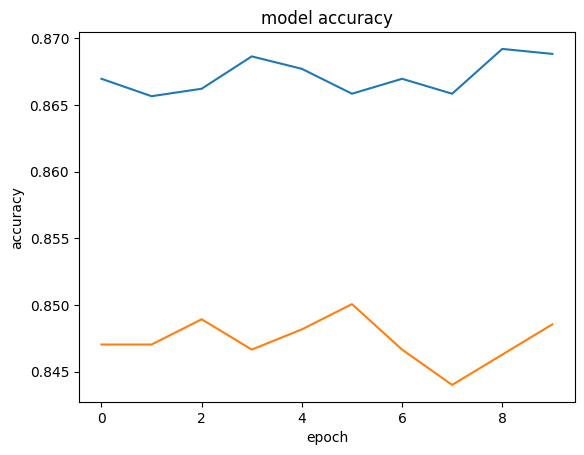

In [47]:
plt.plot(model_histor.history['accuracy'])
plt.plot(model_histor.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

In [37]:
model_history = classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100,callbacks=early_stoping)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8571 - loss: 0.3373 - val_accuracy: 0.8463 - val_loss: 0.3644
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8664 - loss: 0.3282 - val_accuracy: 0.8474 - val_loss: 0.3586
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8692 - loss: 0.3234 - val_accuracy: 0.8482 - val_loss: 0.3594
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8633 - loss: 0.3304 - val_accuracy: 0.8482 - val_loss: 0.3598
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8639 - loss: 0.3267 - val_accuracy: 0.8497 - val_loss: 0.3614
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8684 - loss: 0.3178 - val_accuracy: 0.8466 - val_loss: 0.3624
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8664 - loss: 0.3234 - val_accuracy: 0.8413 - val_loss: 0.3682
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8710 - loss: 0.3147 - val_accu

Text(0.5, 0, 'epoch')

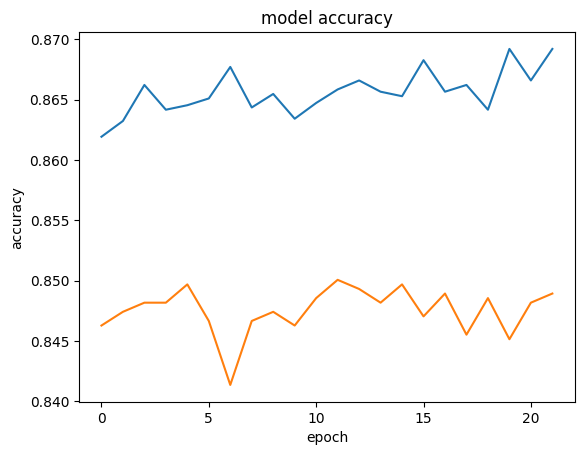

In [48]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')


# Making the prediction and evaluating the model


In [51]:
Y_pred = classifier.predict(X_test)
Y_pred = (Y_pred>=0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [59]:
from sklearn.metrics import confusion_matrix,accuracy_score

In [57]:
cm = confusion_matrix(y_test,Y_pred)
cm

array([[1477,  118],
       [ 179,  226]])

In [61]:
# calulating the accurracy
score = accuracy_score(Y_pred,y_test)
score

0.8515

In [62]:
# seeing the weights
classifier.get_weights()

[array([[-0.15460955,  0.18132563, -0.22465578, -0.0265739 , -0.28643352,
          0.19555503,  0.35977527,  0.16081668,  0.0948445 ,  0.17359813,
         -0.33082652],
        [-0.5078568 , -0.20626919,  0.833999  ,  0.72209066,  0.07832967,
         -0.654555  , -0.14182624,  0.50335044,  0.06747054,  0.09569917,
          0.4372653 ],
        [-0.03096151, -0.08076183,  0.07133187, -0.08167904, -0.25788683,
          0.06928767,  0.17902142, -0.11456506,  0.42792702,  0.11517439,
          0.03060957],
        [ 0.12073679, -0.17849272,  0.09736393, -0.31286854, -0.3856758 ,
          0.6948    , -0.59186554, -0.47639546,  0.21169728,  0.3497749 ,
         -0.4383031 ],
        [ 0.65858024, -0.8935611 , -0.22540103,  0.42338714, -0.04087924,
          0.01538474,  0.29305997, -1.1033812 ,  0.12662101,  1.078563  ,
         -0.4090392 ],
        [ 0.07756141, -0.37805283,  0.21250944, -0.24458626, -0.29951432,
         -0.06684352, -0.29557645, -0.21116616, -0.18197405, -0.1701877